<a href="https://colab.research.google.com/github/angelamunozc/Talento-tech/blob/main/experiencia/Ud_2_ACTIVIDADES_APRENDIZAJE_Red_Neuronal_Convencional_act4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#cargar el conjunto de datos MWIST
mnist = keras.datasets.mnist
#cargue la division de entrenamiento y prueba del conjunto de datos MNIST
(training_images, training_labels), (test_images, test_labels) = mnist.load_data()

In [ ]:
#normalizar los valores de pixeles
training_images = training_images / 255.0
test_images = test_images / 255.0

In [ ]:
#contruir el modelo de claificacion
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)), #inputs
    keras.layers.MaxPooling2D(2, 2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation= 'relu'),
    keras.layers.Dense(10, activation='softmax')])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#compilar el mddelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9991 - loss: 0.0024
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - accuracy: 0.9997 - loss: 0.0014
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 23ms/step - accuracy: 0.9992 - loss: 0.0026
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 23ms/step - accuracy: 0.9993 - loss: 0.0032
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 78s 21ms/step - accuracy: 0.9992 - loss: 0.0025
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 23ms/step - accuracy: 0.9993 - loss: 0.0024
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 20ms/step - accuracy: 0.9999 - loss: 9.1681e-04
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.9998 - loss: 7.6125e-04
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - accuracy: 0.9998 - loss: 8.3697e-04
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 20ms/step - accuracy: 0.9990 - loss: 0.0028


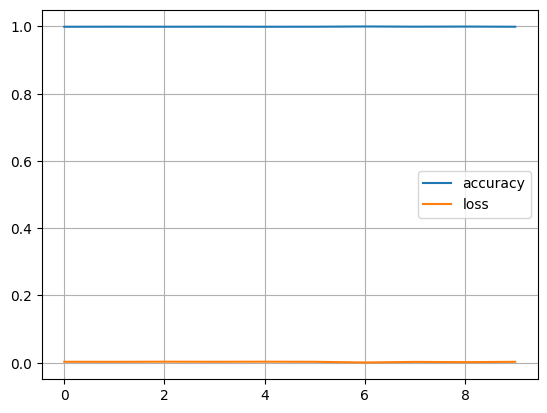

In [ ]:
#entrenar el modelo
history = model.fit(training_images, training_labels, epochs=10)

#graficarl el historial de netrenamiento
pd.DataFrame(history.history).plot(grid=True)
plt.show()

In [ ]:
#evaluar el modelo en el conjunto de entrnamiento
loss, accuracy = model.evaluate(test_images, test_labels)
print("Perdida en el conjunto de entrenamiento:", loss)
print("Exactitud en el conjunto de entrenamiento:", accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0880 - loss: 2.3095
Perdida en el conjunto de entrenamiento: 2.3091979026794434
Exactitud en el conjunto de entrenamiento: 0.09489999711513519


In [ ]:
#evaluar el modelo con datos no vistos
loss, accuracy = model.evaluate(test_images, test_labels)
print("Perdida en el conjunto de prueba:", loss)
print("Exactitud en el conjunto de prueba:", accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0880 - loss: 2.3095
Perdida en el conjunto de prueba: 2.3091979026794434
Exactitud en el conjunto de prueba: 0.09489999711513519


In [ ]:
#predict
index = 1
print(f'Label: {test_labels[index]}')
classifications = model.predict(test_images[index:index+1])
print(f'Classification:\n {classifications.reshape(-1,1)}')

Label: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Classification:
 [[0.11072178]
 [0.09477342]
 [0.10179538]
 [0.09081041]
 [0.09531087]
 [0.10291705]
 [0.11059817]
 [0.09917091]
 [0.09712612]
 [0.09677591]]


In [ ]:
print(test_labels[:30])

[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1]


In [ ]:
FIRST_IMAGE=3
SECOND_IMAGE=10
THIRD_IMAGE=25
print(test_labels[FIRST_IMAGE])
print(test_labels[SECOND_IMAGE])
print(test_labels[THIRD_IMAGE])

0
0
0


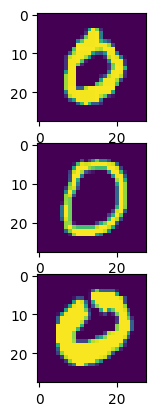

In [ ]:
f, axarr = plt.subplots(3,1)
axarr[0].imshow(test_images[FIRST_IMAGE])
axarr[1].imshow(test_images[SECOND_IMAGE])
axarr[2].imshow(test_images[THIRD_IMAGE])


In [ ]:
layer = 0
filtre1 = 0
filtre2 = 10

layer_outputs = [layer.output for layer in model.layers]
activation_model = keras.models.Model(inputs = model.input, outputs = layer_outputs)

AttributeError: The layer sequential_1 has never been called and thus has no defined input.

In [ ]:
f, axarr = plt.subplots(3,3)


axarr[0, 0].set.title("Image Input")
axarr[0, 0].imshow(test_images[FIRST_IMAGE])
f1 = activation_model.predict(test_images[FIRST_IMAGE].reshape(1, 28, 28, 1))[layer]
axarr[0, 1].set.title("Layer"+str(layer)+", Filter1")
axarr[0, 1].imshow(f1[0, :, :, filtre1])
axarr[0, 2].set.title("Layer"+str(layer)+", Filter2")
axarr[0, 2].imshow(f1[0, :, :, filtre2])

axarr[1, 0].imshow(test_images[SECOND_IMAGE])
f2 = activation_model.predict(test_images[SECOND_IMAGE].reshape(1, 28, 28, 1))[layer]
axarr[1, 1].imshow(f2[0, :, :, filtre1])
axarr[1, 0].imshow(f2[0, :, :, filtre2])

axarr[2, 0].imshow(test_images[THIRD_IMAGE])
f3 = activation_model.predict(test_images[THIRD_IMAGE].reshape(1, 28, 28, 1))[layer]
axarr[2, 1].imshow(f3[0, :, :, filtre1])
axarr[2, 2].imshow(f3[0, :, :, filtre2])


In [ ]:
FIRST_IMAGE=2
SECOND_IMAGE=5
THIRD_IMAGE=14